# GliZNet — Trained Model Exploration

Checkpoint: `results/deberta-v3-base_20260425_213633/checkpoint-850`

Sections:
1. Load model & test set  
2. Run predictions on test set  
3. Ranking metrics (Hit@k, NDCG@k, MRR, AUC)  
4. Score distribution  
5. Good predictions — model nailed it  
6. Bad predictions — model failed  
7. Edge cases — ambiguous / borderline samples

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

from gliznet.predictor import ZeroShotClassificationPipeline
from gliznet.data import load_dataset
from gliznet.metrics import compute_metrics, _sigmoid

CHECKPOINT = "../results/deberta-v3-base_20260428_094151/checkpoint-9666"
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {DEVICE}")

Device: cuda


## 1 · Load model & test set

In [2]:
pipeline = ZeroShotClassificationPipeline.from_pretrained(CHECKPOINT, device=DEVICE)
print("✓ Model loaded")
print(f"  Parameters : {sum(p.numel() for p in pipeline.model.parameters()):,}")
print(f"  dtype      : {next(pipeline.model.parameters()).dtype}")

Loading weights:   0%|          | 0/208 [00:00<?, ?it/s]

✓ Model loaded
  Parameters : 185,410,562
  dtype      : torch.float32


In [3]:
test_ds = load_dataset(
    path="alexneakameni/ZSHOT-HARDSET-v2",
    split="test",
    shuffle_labels=False,   # keep positives first for easier inspection
    min_label_length=3,
)
print(f"✓ Test set loaded: {len(test_ds)} samples")
print(f"  Columns: {test_ds.column_names}")
print(f"\nSample:")
ex = test_ds[0]
print(f"  text   : {ex['text'][:120]}...")
print(f"  labels : {ex['ltext']}")
print(f"  targets: {ex['lint']}")

Map:   0%|          | 0/1528 [00:00<?, ? examples/s]

Filter:   0%|          | 0/1528 [00:00<?, ? examples/s]

✓ Test set loaded: 1527 samples
  Columns: ['text', 'ltext', 'lint']

Sample:
  text   : Development Executive position for a major studio focused on acquiring and greenlighting prestige television projects. M...
  labels : ['anthology_series_casting', 'award_recognition_background', 'dramatic_performance_range', 'prestige_television_experience', 'television_drama_focus', 'acting_coaching_experience', 'guest_appearance_versatility', 'off_broadway_credentials']
  targets: [1, 1, 1, 1, 1, 0, 0, 0]


## 2 · Run predictions on full test set

In [4]:
from tqdm.auto import tqdm

BATCH_SIZE = 32
records = []

for i in tqdm(range(0, len(test_ds), BATCH_SIZE), desc="Predicting"):
    batch = test_ds[i : i + BATCH_SIZE]
    texts  = batch["text"]
    labels = batch["ltext"]
    gts    = batch["lint"]

    outputs = pipeline(texts, labels)
    if not isinstance(outputs, list):
        outputs = [outputs]

    for out, gt_labels, gt_ints in zip(outputs, labels, gts):
        # build aligned score list in the same order as labels
        score_map = {ls.label: ls.score for ls in out.labels}
        scores = [score_map.get(l, 0.0) for l in gt_labels]

        records.append({
            "text":     out.text,
            "labels":   gt_labels,
            "targets":  gt_ints,
            "scores":   scores,
        })

print(f"✓ Predictions done: {len(records)} samples")

# Quick sanity check
r = records[0]
for lbl, tgt, sc in zip(r["labels"], r["targets"], r["scores"]):
    print(f"  [{tgt}] {lbl:<30s}  score={sc:.3f}")

Predicting:   0%|          | 0/48 [00:00<?, ?it/s]

✓ Predictions done: 1527 samples
  [1] anthology_series_casting        score=0.879
  [1] award_recognition_background    score=0.829
  [1] dramatic_performance_range      score=0.056
  [1] prestige_television_experience  score=0.930
  [1] television_drama_focus          score=0.936
  [0] acting_coaching_experience      score=0.046
  [0] guest_appearance_versatility    score=0.047
  [0] off_broadway_credentials        score=0.502


## 3 · Ranking metrics

In [5]:
from sklearn.metrics import roc_auc_score, average_precision_score
from gliznet.metrics import _ndcg_at_k

KS = (1, 3, 5, 10)

hits  = {k: [] for k in KS}
ndcgs = {k: [] for k in KS}
rr, aucs, aps = [], [], []
per_sample_mrr = []

for r in records:
    s = np.array(r["scores"], dtype=float)
    g = np.array(r["targets"], dtype=float)

    if g.sum() == 0:
        continue

    ranked = g[np.argsort(-s)]

    for k in KS:
        hits[k].append(float(ranked[:k].any()))
        ndcgs[k].append(_ndcg_at_k(ranked, k))

    pos_ranks = np.where(ranked > 0.5)[0]
    mrr_val = 1.0 / (pos_ranks[0] + 1) if len(pos_ranks) else 0.0
    rr.append(mrr_val)
    per_sample_mrr.append(mrr_val)

    if len(np.unique(g)) > 1:
        probs = _sigmoid(s)
        try:
            aucs.append(roc_auc_score(g, probs))
            aps.append(average_precision_score(g, probs))
        except ValueError:
            pass

metrics_summary = {}
for k in KS:
    metrics_summary[f"Hit@{k}"]  = np.mean(hits[k])
    metrics_summary[f"NDCG@{k}"] = np.mean(ndcgs[k])
metrics_summary["MRR"]           = np.mean(rr)
metrics_summary["ROC-AUC"]       = np.mean(aucs)
metrics_summary["Avg Precision"] = np.mean(aps)
metrics_summary["N samples"]     = len(rr)

df_metrics = pd.DataFrame(metrics_summary, index=["score"]).T
df_metrics.columns = ["value"]
df_metrics["value"] = df_metrics["value"].map(lambda x: f"{x:.4f}" if isinstance(x, float) else x)
df_metrics

,value
Hit@1,0.8815
NDCG@1,0.8815
Hit@3,0.9974
NDCG@3,0.8794
Hit@5,1.0000
NDCG@5,0.9064
Hit@10,1.0000
NDCG@10,0.9466
MRR,0.9381
ROC-AUC,0.8854


## 4 · Score distributions

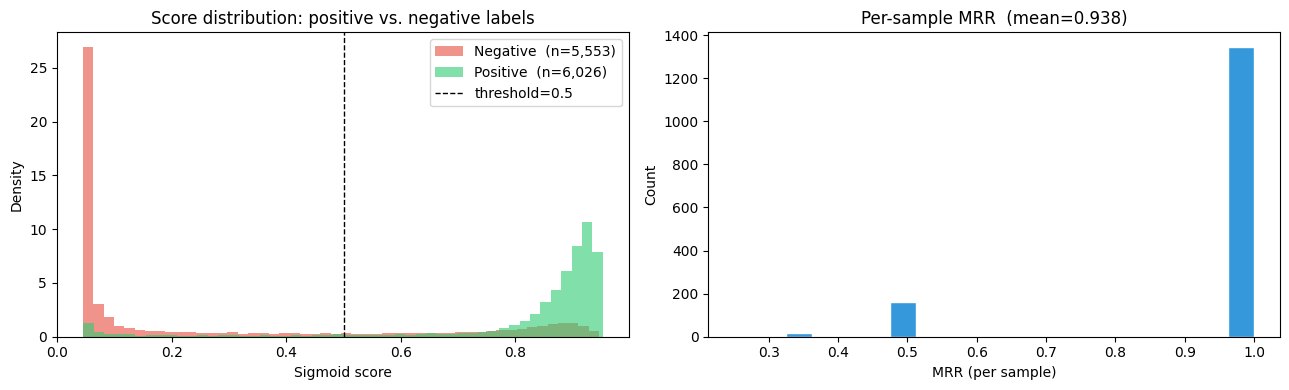

In [6]:
pos_scores, neg_scores = [], []
for r in records:
    for sc, tgt in zip(r["scores"], r["targets"]):
        if tgt == 1:
            pos_scores.append(sc)
        else:
            neg_scores.append(sc)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# --- Score histogram ---
axes[0].hist(neg_scores, bins=50, alpha=0.6, color="#e74c3c", label=f"Negative  (n={len(neg_scores):,})", density=True)
axes[0].hist(pos_scores, bins=50, alpha=0.6, color="#2ecc71", label=f"Positive  (n={len(pos_scores):,})", density=True)
axes[0].axvline(0.5, color="k", linestyle="--", linewidth=1, label="threshold=0.5")
axes[0].set_xlabel("Sigmoid score"); axes[0].set_ylabel("Density")
axes[0].set_title("Score distribution: positive vs. negative labels")
axes[0].legend()

# --- MRR per-sample histogram ---
axes[1].hist(per_sample_mrr, bins=20, color="#3498db", edgecolor="white")
axes[1].set_xlabel("MRR (per sample)"); axes[1].set_ylabel("Count")
axes[1].set_title(f"Per-sample MRR  (mean={np.mean(per_sample_mrr):.3f})")

plt.tight_layout()
plt.show()

## 5 · Good predictions — model nailed it

Samples where the top-1 predicted label is correct (MRR = 1.0).

In [7]:
def show_prediction(r, title=None, n_show=8):
    """Pretty-print a single prediction result."""
    if title:
        print(f"\n{'='*70}\n{title}\n{'='*70}")
    text = r["text"]
    print(f"TEXT: {text[:200]}{'...' if len(text)>200 else ''}\n")
    print(f"{'Label':<35} {'Target':>7}  {'Score':>7}  {'Rank':>5}")
    print("-" * 60)
    order = np.argsort(-np.array(r["scores"]))
    for rank, idx in enumerate(order[:n_show], 1):
        lbl = r["labels"][idx]
        tgt = r["targets"][idx]
        sc  = r["scores"][idx]
        marker = "✓" if tgt == 1 else " "
        print(f"{marker} {lbl:<33} {tgt:>7}  {sc:>7.3f}  #{rank}")
    print()


# Find samples with MRR == 1 (rank-1 hit)
good = [
    (r, mrr)
    for r, mrr in zip(records, per_sample_mrr)
    if mrr == 1.0
]
print(f"Samples with top-1 correct: {len(good)} / {len(records)}  ({100*len(good)/len(records):.1f}%)\n")

import random
random.seed(42)
for r, _ in random.sample(good, min(5, len(good))):
    show_prediction(r)

Samples with top-1 correct: 1346 / 1527  (88.1%)

TEXT: I can confirm from reviewing official documents that on February twelfth, two thousand twenty, the United Nations published a database that included our organization. This listing was based on our bus...

Label                                Target    Score   Rank
------------------------------------------------------------
✓ documentary_evidence                    1    0.928  #1
✓ chronological_certainty                 1    0.928  #2
✓ factual_assertion                       1    0.916  #3
  qualified_statement                     0    0.786  #4
✓ consequence_statement                   1    0.051  #5
  causal_claim                            0    0.046  #6
  personal_observation                    0    0.046  #7

TEXT: This draft exhibits commendable comprehensiveness in event coverage but appears to lack analytical depth in several key areas. The coalition government restructuring is presented as procedural fact wi...

Label  

## 6 · Bad predictions — model failed

Samples where MRR = 0 (the first positive label was never found in the ranked list).

In [8]:
bad = [
    (r, mrr)
    for r, mrr in zip(records, per_sample_mrr)
    if mrr == 0.0
]
print(f"Samples with MRR=0: {len(bad)} / {len(records)}  ({100*len(bad)/len(records):.1f}%)\n")

for r, _ in random.sample(bad, min(5, len(bad))):
    show_prediction(r)

Samples with MRR=0: 0 / 1527  (0.0%)



## 7 · Edge cases — borderline samples

Samples where MRR is middling (0 < MRR < 1): the model partially ranked positives correctly but not first.

In [9]:
borderline = [
    (r, mrr)
    for r, mrr in zip(records, per_sample_mrr)
    if 0.0 < mrr < 1.0
]
print(f"Borderline samples (0 < MRR < 1): {len(borderline)} / {len(records)}  ({100*len(borderline)/len(records):.1f}%)\n")

# Sort by MRR ascending — hardest borderline cases first
borderline.sort(key=lambda x: x[1])
for r, mrr in borderline[:5]:
    show_prediction(r, title=f"MRR = {mrr:.3f}")

Borderline samples (0 < MRR < 1): 181 / 1527  (11.9%)


MRR = 0.250
TEXT: The settlement's identity is anchored to the lake's southern terminus, where the water body defines both a recreational resource and a geographical limit. The observer notes how this lake-edge positio...

Label                                Target    Score   Rank
------------------------------------------------------------
  regional_positioning_significance       0    0.930  #1
  geographical_reference_pointing         0    0.929  #2
  symbolic_geographical_positioning       0    0.927  #3
✓ regional_integration_narrative          1    0.922  #4
✓ lake_edge_identity                      1    0.921  #5
  provincial_integration                  0    0.087  #6
✓ infrastructural_connectivity            1    0.046  #7
  cross_border_cultural_exchange          0    0.046  #8


MRR = 0.250
TEXT: I finally understand what they meant about were music being for the living and the dead. Tonight my father asked me to play 

## 8 · Hit@k bar chart

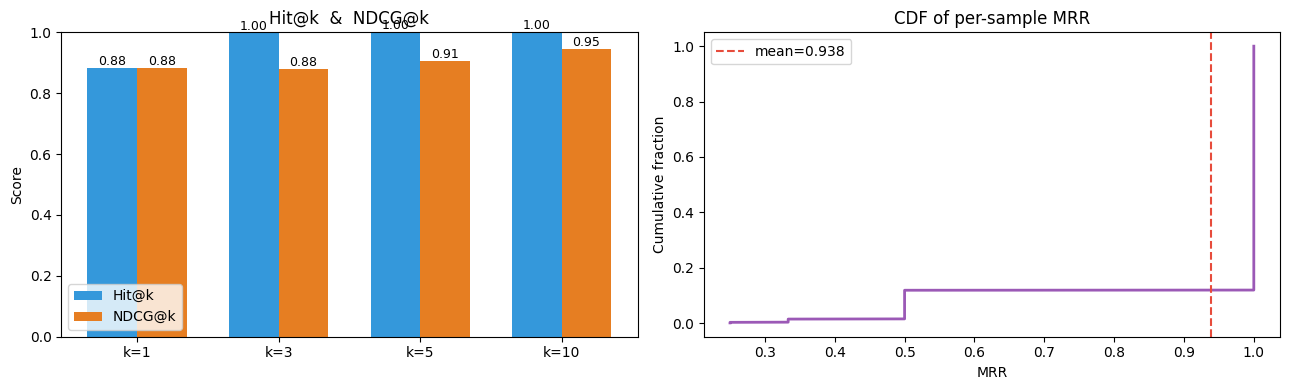

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Hit@k
k_vals  = list(KS)
hit_vals  = [np.mean(hits[k]) for k in k_vals]
ndcg_vals = [np.mean(ndcgs[k]) for k in k_vals]

x = np.arange(len(k_vals))
width = 0.35

axes[0].bar(x - width/2, hit_vals,  width, label="Hit@k",   color="#3498db")
axes[0].bar(x + width/2, ndcg_vals, width, label="NDCG@k",  color="#e67e22")
axes[0].set_xticks(x); axes[0].set_xticklabels([f"k={k}" for k in k_vals])
axes[0].set_ylim(0, 1); axes[0].set_ylabel("Score")
axes[0].set_title("Hit@k  &  NDCG@k")
axes[0].legend()
for i, (h, n) in enumerate(zip(hit_vals, ndcg_vals)):
    axes[0].text(i - width/2, h + 0.01, f"{h:.2f}", ha="center", fontsize=9)
    axes[0].text(i + width/2, n + 0.01, f"{n:.2f}", ha="center", fontsize=9)

# MRR distribution as CDF
sorted_mrr = np.sort(per_sample_mrr)
cdf = np.arange(1, len(sorted_mrr)+1) / len(sorted_mrr)
axes[1].plot(sorted_mrr, cdf, color="#9b59b6", linewidth=2)
axes[1].axvline(np.mean(per_sample_mrr), color="#e74c3c", linestyle="--", label=f"mean={np.mean(per_sample_mrr):.3f}")
axes[1].set_xlabel("MRR"); axes[1].set_ylabel("Cumulative fraction")
axes[1].set_title("CDF of per-sample MRR")
axes[1].legend()

plt.tight_layout()
plt.show()